In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.decomposition import PCA
from sklearn.svm import SVC

df = pd.read_csv('abalone.csv')

df.head()

,Sex,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4177 entries, 0 to 4176
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sex             4177 non-null   object 
 1   Length          4177 non-null   float64
 2   Diameter        4177 non-null   float64
 3   Height          4177 non-null   float64
 4   Whole weight    4177 non-null   float64
 5   Shucked weight  4177 non-null   float64
 6   Viscera weight  4177 non-null   float64
 7   Shell weight    4177 non-null   float64
 8   Rings           4177 non-null   int64  
dtypes: float64(7), int64(1), object(1)
memory usage: 293.8+ KB


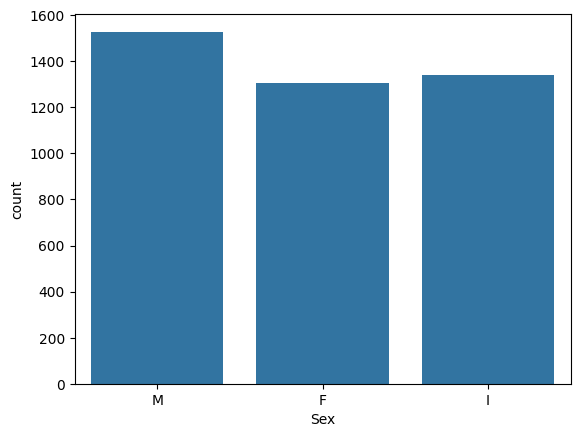

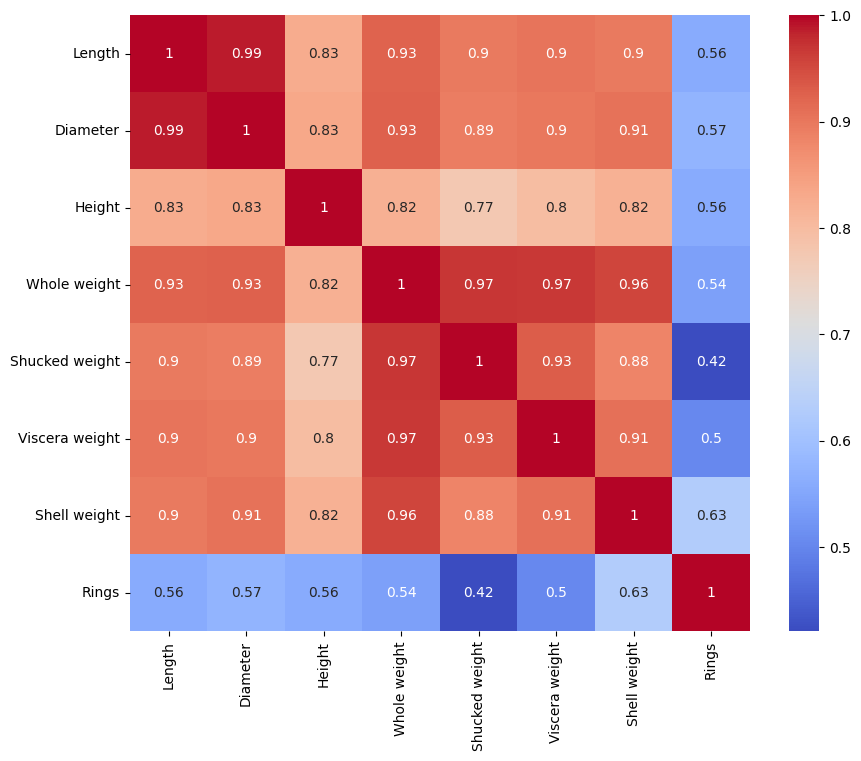

In [2]:
df.info()

df.describe()

df.isnull().sum()

sns.countplot(x='Sex', data=df)
plt.show()

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

In [3]:
le=LabelEncoder()
df['Sex']=le.fit_transform(df['Sex'])

X=df.drop('Rings', axis=1)
y=df['Rings']

y=(y>y.median()).astype(int)

X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=42)

scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [4]:
lr=LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)

y_pred=lr.predict(X_test_scaled)

In [5]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7906698564593302

Confusion Matrix:
 [[341  80]
 [ 95 320]]

Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.81      0.80       421
           1       0.80      0.77      0.79       415

    accuracy                           0.79       836
   macro avg       0.79      0.79      0.79       836
weighted avg       0.79      0.79      0.79       836



In [6]:
pca=PCA()
X_train_pca=pca.fit_transform(X_train_scaled)
X_test_pca=pca.transform(X_test_scaled)

print("Explained Variance Ratio:\n", pca.explained_variance_ratio_)

Explained Variance Ratio:
 [7.92243974e-01 1.25099486e-01 3.67981713e-02 2.11514241e-02
 1.45081574e-02 7.94353732e-03 1.52950441e-03 7.25745220e-04]


In [7]:
pca=PCA(n_components=5)
X_train_pca=pca.fit_transform(X_train_scaled)
X_test_pca=pca.transform(X_test_scaled)

lr_pca=LogisticRegression(max_iter=1000)
lr_pca.fit(X_train_pca, y_train)

y_pred_lr_pca=lr_pca.predict(X_test_pca)

In [8]:
svc=SVC()
svc.fit(X_train_pca, y_train)

y_pred_svc=svc.predict(X_test_pca)

In [9]:
print("Logistic Regression with PCA")
print("Accuracy:", accuracy_score(y_test, y_pred_lr_pca))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr_pca))
print("Classification Report:\n", classification_report(y_test, y_pred_lr_pca))

print("\nSVM with PCA")
print("Accuracy:", accuracy_score(y_test, y_pred_svc))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svc))
print("Classification Report:\n", classification_report(y_test, y_pred_svc))

Logistic Regression with PCA
Accuracy: 0.7834928229665071
Confusion Matrix:
 [[335  86]
 [ 95 320]]
Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.80      0.79       421
           1       0.79      0.77      0.78       415

    accuracy                           0.78       836
   macro avg       0.78      0.78      0.78       836
weighted avg       0.78      0.78      0.78       836


SVM with PCA
Accuracy: 0.7811004784688995
Confusion Matrix:
 [[311 110]
 [ 73 342]]
Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.74      0.77       421
           1       0.76      0.82      0.79       415

    accuracy                           0.78       836
   macro avg       0.78      0.78      0.78       836
weighted avg       0.78      0.78      0.78       836

